# Crear estado de inicio para pp_reset

Este notebook construye el dict `final_state_sp_set` que necesita `PP_reset` para arrancar,
y lo guarda en `Init_data/` usando `save_phase_state`.

Una vez guardado, puedes lanzar la simulación desde `pp_reset` con:
```bash
python -m RRAM exec <num_simulation> --start-from pp_reset
```

## Variables que necesita PP_reset

| Clave | Tipo | Descripción |
|-------|------|-------------|
| `actual_state` | `ndarray (eje_x, eje_y) bool` | Red de vacantes de oxígeno. `True` = vacante. |
| `Temperatura_final` | `ndarray (eje_x, eje_y+2) float` | Perfil de temperatura (incluye columnas de electrodo). |
| `percola` | `bool` | `True` si el dispositivo está en LRS (filamento formado). |
| `centros_calculados` | `list[int]` | Fila central de cada filamento. |
| `tiempo_sp_set` | `float` | Tiempo acumulado al final de SP_set (s). |
| `params` | `SimulationParameters` | Se inyecta automáticamente del CSV al cargar. |
| `sim_ctes` | `SimulationConstants` | Se inyecta automáticamente del CSV al cargar. |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from RRAM import Percolation, utils
from RRAM.init_simulation import load_simulation_config
from RRAM.persistence import PHASE_PRECEDING, save_phase_state

## 1 · Configuración

In [2]:
# ── Ajusta estos valores ──────────────────────────────────────────────────
NUM_SIMULATION = 0        # índice 0-based en el CSV
INIT_DATA_DIR  = Path("Init_data")
# ─────────────────────────────────────────────────────────────────────────

# n_save es el ID que usa run_cycle internamente (num_simulation + 1)
n_save = NUM_SIMULATION + 1
print(f"Simulación {NUM_SIMULATION}  →  n_save = {n_save}")
print(f"El estado se guardará en: {INIT_DATA_DIR / f'phase_state_{n_save}_sp_set.*'}")

Simulación 0  →  n_save = 1
El estado se guardará en: Init_data/phase_state_1_sp_set.*


## 2 · Cargar configuración de la simulación

In [3]:
cfg = load_simulation_config(
    num_simulation=NUM_SIMULATION,
    init_data_dir=INIT_DATA_DIR,
)

params   = cfg.params
sim_ctes = cfg.sim_ctes

eje_x = params.y_size   # número de filas de la red
eje_y = params.x_size   # número de columnas (dirección de la corriente)

print(f"Dimensiones de la red: {eje_x} filas × {eje_y} columnas")
print(f"Temperatura ambiente  : {params.init_temp} K")
print(f"Rangos de filamentos  : {cfg.cf_ranges}")
print(f"Centros de filamentos : {cfg.cf_centros}")
print(f"Num. filamentos       : {sim_ctes.num_filamentos}")
print(f"Grosor filamento      : {sim_ctes.grosor_filamento}")

Dimensiones de la red: 60 filas × 40 columnas
Temperatura ambiente  : 300.0 K
Rangos de filamentos  : [(0, 29), (30, 59)]
Centros de filamentos : [14, 44]
Num. filamentos       : 2
Grosor filamento      : [3, 1]


## 3 · Estado del dispositivo (`actual_state`)

Para comenzar en `pp_reset` el dispositivo debe estar en **LRS** (filamento formado, percolación activa).  
Aquí partimos del estado inicial aleatorio cargado en `Init_data/` y añadimos
una franja de vacantes en la zona de cada filamento para garantizar la percolación.

> Si ya tienes un `actual_state` de una ejecución anterior (p.ej. del archivo
> `Data_sp_set_N.npz`), cárgalo directamente en la celda alternativa de abajo
> y salta la generación manual.

In [4]:
# ── Opción A: partir del init_state y forzar filamento ───────────────────
init_state_path = INIT_DATA_DIR / f"init_state_{NUM_SIMULATION}"
actual_state = utils.cargar_estado(init_state_path).astype(bool)
print(f"Estado inicial cargado: shape={actual_state.shape}, "
      f"vacantes={actual_state.sum()} / {actual_state.size}")

Estado inicial cargado: shape=(60, 40), vacantes=90 / 2400


In [5]:
# ── Opción B (alternativa): cargar desde un resultado previo ─────────────
# Descomenta y ajusta la ruta si quieres usar un estado ya simulado.
#
# RESULTS_DIR = Path("Results")
# data_sp_set = np.load(RESULTS_DIR / f"simulation_{n_save}" / f"Data_sp_set_{n_save}.npz")
# actual_state = data_sp_set["actual_state"].astype(bool)
# print(f"Estado cargado de Results: shape={actual_state.shape}")

### 3.1 · Crear filamento percolante

Añadimos una franja horizontal de vacantes en la zona central de cada filamento.
El grosor de la franja se toma de `sim_ctes.grosor_filamento`.

In [6]:
def crear_franja_percolante(
    state: np.ndarray,
    cf_ranges: list,
    cf_centros: list,
    grosor_filamento,
) -> np.ndarray:
    """Activa (=True) una franja horizontal en la zona de cada filamento."""
    state = state.copy()

    for idx, (row_min, row_max) in enumerate(cf_ranges):
        centro = cf_centros[idx]

        # grosor_filamento puede ser un int o una lista [grosor_fil_1, grosor_fil_2, ...]
        if isinstance(grosor_filamento, (list, tuple, np.ndarray)):
            grosor = int(grosor_filamento[idx]) if idx < len(grosor_filamento) else int(grosor_filamento[-1])
        else:
            grosor = int(grosor_filamento)

        # Filas que ocupa el filamento (centradas en `centro`, ancho = grosor)
        mitad = grosor // 2
        fila_ini = max(row_min, centro - mitad)
        fila_fin = min(row_max + 1, centro + mitad + 1)

        # Activar toda la franja (columna 0 → columna -1) para garantizar percolación
        state[fila_ini:fila_fin, :] = True
        print(f"Filamento {idx}: filas [{fila_ini}, {fila_fin}) activadas "
              f"(centro={centro}, grosor={grosor})")

    return state


actual_state = crear_franja_percolante(
    actual_state,
    cf_ranges=cfg.cf_ranges,
    cf_centros=cfg.cf_centros,
    grosor_filamento=sim_ctes.grosor_filamento,
)

print(f"\nVacantes tras crear filamento: {actual_state.sum()} / {actual_state.size}")

Filamento 0: filas [13, 16) activadas (centro=14, grosor=3)
Filamento 1: filas [44, 45) activadas (centro=44, grosor=1)

Vacantes tras crear filamento: 250 / 2400


## 4 · Verificar percolación

In [7]:
percola_global = Percolation.is_path(actual_state.astype(int))
print(f"Percolación global: {percola_global}")

# Verificar también por zona de filamento
for idx, (row_min, row_max) in enumerate(cfg.cf_ranges):
    zona = actual_state[row_min:row_max + 1, :].astype(int)
    percola_zona = Percolation.is_path(zona)
    print(f"  Filamento {idx} (filas {row_min}–{row_max}): percola = {percola_zona}")

if not percola_global:
    print("\n⚠  El dispositivo NO percola. PP_reset necesita que percola=True "
          "para simular correctamente el proceso de rotura de filamento.")
    print("   Revisa la celda anterior o ajusta las filas del filamento manualmente.")

Percolación global: True
  Filamento 0 (filas 0–29): percola = True
  Filamento 1 (filas 30–59): percola = True


## 5 · Temperatura inicial (`Temperatura_final`)

`Temperatura_final` tiene forma `(eje_x, eje_y + 2)`: la red más una columna de electrodo
a cada lado. PP_reset usa `Temperatura_final[:, 1:-1]` para acceder al dominio interior.

In [8]:
# Inicializar uniformemente a temperatura ambiente
Temperatura_final = np.full(
    (eje_x, eje_y + 2),
    fill_value=float(params.init_temp),
    dtype=np.float64,
)

print(f"Temperatura_final shape: {Temperatura_final.shape}")
print(f"Valor uniforme: {Temperatura_final[0, 0]:.1f} K")

Temperatura_final shape: (60, 42)
Valor uniforme: 300.0 K


## 6 · Resto de parámetros del estado

In [9]:
# ── Ajusta si es necesario ────────────────────────────────────────────────
percola          = percola_global   # True si el dispositivo percola
centros_calculados = list(cfg.cf_centros)  # lista de filas centrales de cada filamento
tiempo_sp_set    = 0.0              # tiempo acumulado hasta este punto (segundos)
# ─────────────────────────────────────────────────────────────────────────

print(f"percola             : {percola}")
print(f"centros_calculados  : {centros_calculados}")
print(f"tiempo_sp_set       : {tiempo_sp_set} s")

percola             : True
centros_calculados  : [14, 44]
tiempo_sp_set       : 0.0 s


## 7 · Visualizar el estado

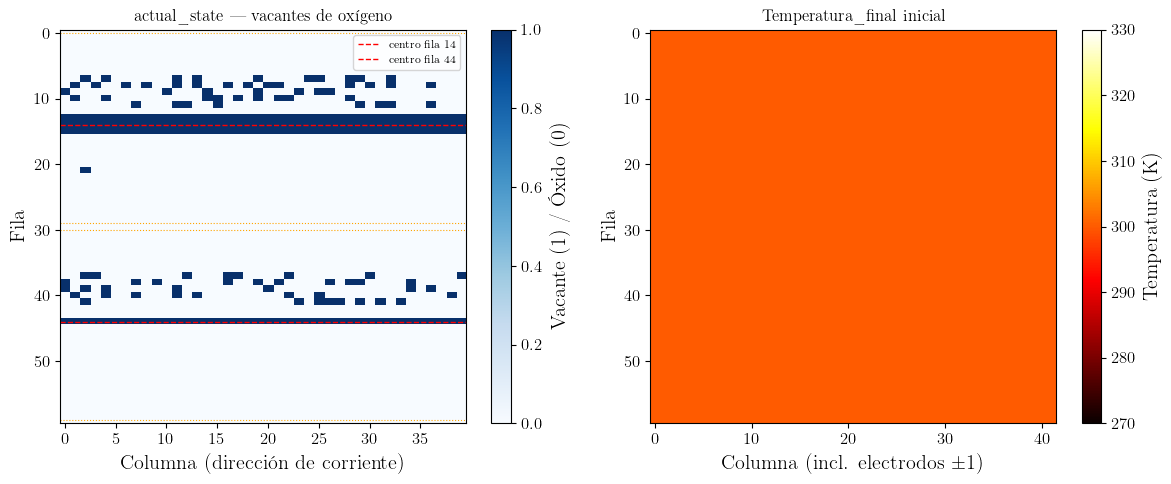

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Estado de vacantes ---
ax = axes[0]
im = ax.imshow(actual_state.astype(int), cmap="Blues", aspect="auto",
               origin="upper", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Vacante (1) / Óxido (0)")
ax.set_title("actual_state — vacantes de oxígeno")
ax.set_xlabel("Columna (dirección de corriente)")
ax.set_ylabel("Fila")

# Marcar centros de filamentos
for centro in centros_calculados:
    ax.axhline(centro, color="red", linewidth=1, linestyle="--", label=f"centro fila {centro}")
ax.legend(fontsize=8, loc="upper right")

# Marcar rangos de filamentos
for row_min, row_max in cfg.cf_ranges:
    ax.axhline(row_min, color="orange", linewidth=0.8, linestyle=":")
    ax.axhline(row_max, color="orange", linewidth=0.8, linestyle=":")

# --- Perfil de temperatura ---
ax2 = axes[1]
im2 = ax2.imshow(Temperatura_final, cmap="hot", aspect="auto", origin="upper")
plt.colorbar(im2, ax=ax2, label="Temperatura (K)")
ax2.set_title("Temperatura_final inicial")
ax2.set_xlabel("Columna (incl. electrodos ±1)")
ax2.set_ylabel("Fila")

plt.tight_layout()
plt.show()

## 8 · Construir el dict y guardar

El dict reproduce exactamente la estructura que devuelve `SP_set`.
`params` y `sim_ctes` se omiten del archivo (se inyectan desde el CSV al cargar).

In [11]:
final_state_sp_set = {
    "actual_state"      : actual_state,
    "sim_ctes"          : sim_ctes,          # se omite al guardar, se reconstruye del CSV
    "params"            : params,            # idem
    "Temperatura_final" : Temperatura_final,
    "percola"           : percola,
    "centros_calculados": centros_calculados,
    "tiempo_sp_set"     : tiempo_sp_set,
}

print("Dict final_state_sp_set:")
for k, v in final_state_sp_set.items():
    if hasattr(v, "shape"):
        print(f"  {k:25s}: ndarray {v.shape} {v.dtype}")
    else:
        print(f"  {k:25s}: {type(v).__name__} = {v}")

Dict final_state_sp_set:
  actual_state             : ndarray (60, 40) bool
  sim_ctes                 : SimulationConstants = Las constantes de la simulación son:
   vibration_frequency=10000000000000.0,
   cte_red=2.5e-10,
   permitividad_relativa_set=299.9526,
   permitividad_relativa_reset=299.9675,
   generation_energy=1.09,
   recombination_energy=1.55,
   pb_metal_insul_set=0.001,
   pb_metal_insul_reset=0.0325,
   recom_enchancement_factor=3000.0,
   long_decaimiento_concentracion=1e-09,
   ohm_resistence_set=4.1,
   ohm_resistence_reset=4.1,
   num_filamentos=2,
   grosor_filamento=[3, 1],
   gamma=10.0,
   gamma_drift=10.0,
   E_m=0.6,
   I_0_set=0.0019283,
   I_0_reset=0.0045414,
   r_termica_no_percola=10000.0,
   conductividad_termica_dielectrico=2.3,
   conductividad_termica_CF=15.0,
   conductividad_termica_aislante=1e-06,
   conductividad_termica_electrodo=5.0,
   Temperatura_electrodo=300.0,
   factor_generar_calor=5.5e-05,
   pendiente_temperatura=-24.7,
   ocupacion_

In [12]:
save_phase_state(
    state_dict     = final_state_sp_set,
    phase_name     = "sp_set",
    num_simulation = n_save,
    init_data_dir  = INIT_DATA_DIR,
)

npz_path  = INIT_DATA_DIR / f"phase_state_{n_save}_sp_set.npz"
json_path = INIT_DATA_DIR / f"phase_state_{n_save}_sp_set.json"
print(f"\nGuardado:")
print(f"  {npz_path}  →  existe: {npz_path.is_file()}")
print(f"  {json_path} →  existe: {json_path.is_file()}")


Guardado:
  Init_data/phase_state_1_sp_set.npz  →  existe: True
  Init_data/phase_state_1_sp_set.json →  existe: True


## 9 · Verificar que la carga funciona

Comprueba que `load_phase_state` reconstruye correctamente el dict antes de lanzar la simulación.

In [13]:
from RRAM.persistence import load_phase_state

estado_cargado = load_phase_state(
    phase_name     = "sp_set",
    num_simulation = n_save,
    init_data_dir  = INIT_DATA_DIR,
    cfg            = cfg,
)

print("Claves del dict cargado:")
for k, v in estado_cargado.items():
    if hasattr(v, "shape"):
        print(f"  {k:25s}: ndarray {v.shape} {v.dtype}")
    else:
        print(f"  {k:25s}: {type(v).__name__} = {v}")

# Verificar que actual_state se ha conservado correctamente
assert np.array_equal(estado_cargado["actual_state"], actual_state), \
    "actual_state no coincide tras el round-trip"
assert np.allclose(estado_cargado["Temperatura_final"], Temperatura_final), \
    "Temperatura_final no coincide tras el round-trip"
print("\n✓ Round-trip correcto. Listo para lanzar:")
print(f"  python -m RRAM exec {NUM_SIMULATION} --start-from pp_reset")

Claves del dict cargado:
  percola                  : bool = True
  centros_calculados       : list = [14, 44]
  tiempo_sp_set            : float = 0.0
  actual_state             : ndarray (60, 40) bool
  Temperatura_final        : ndarray (60, 42) float64
  params                   : SimulationParameters = Los parámetros de la simulación son:
   device_size_x=1e-08,
   device_size_y=1.5e-08,
   atom_size=2.5e-10,
   num_trampas=90,
   total_simulation_time=10.0,
   num_pasos=10000,
   voltaje_final_reset=1.4,
   voltaje_final_set=1.1,
   init_temp=300.0,
   x_size=40,
   y_size=60,
   num_max_vacantes=2280,
   paso_temporal=0.001,
   paso_potencial_set=0.00011,
   paso_potencial_reset=0.00014

  sim_ctes                 : SimulationConstants = Las constantes de la simulación son:
   vibration_frequency=10000000000000.0,
   cte_red=2.5e-10,
   permitividad_relativa_set=299.9526,
   permitividad_relativa_reset=299.9675,
   generation_energy=1.09,
   recombination_energy=1.55,
   pb_meta